# Tutorial - Manejo de datos
Sergio Cabrales, Universidad de los Andes

https://www.sac2.com/

## 1. Carga de librerías, funciones y APIs necesarias.

#### 1.1. Instalan las librerías que no incluye Google Colab

In [1]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install mplfinance

Note: you may need to restart the kernel to use updated packages.


#### 1.2. Se cargan las librerías requeridas

In [3]:
# Funciones numéricas adicionales
import numpy as np

# Lectura de datos y manejo de Data-sets
import pandas as pd

# Datos
import yfinance as yfin

# Gráficos
import matplotlib.pyplot as plt

#analisis tecnico
import mplfinance as mpf

## 2. Obtención de datos históricos

#### 2.1. Descarga de datos desde Yahoo Finance

https://finance.yahoo.com/


In [4]:
# Descargamos datos de la acción sleccionada:
df = yfin.download('AAPL', start='2021-01-01', multi_level_index=False)
df

C:\Rtemp\ipykernel_24580\119865742.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yfin.download('AAPL', start='2021-01-01', multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2021-01-04,125.632515,129.709914,123.059867,129.622544,143301900
2021-01-05,127.185799,127.894501,124.681107,125.127686,97664900
2021-01-06,122.904518,127.224626,122.690939,123.991828,155088000
2021-01-07,127.098412,127.787693,124.127736,124.613141,109578200
2021-01-08,128.195435,128.758506,126.428554,128.564332,105158200
...,...,...,...,...,...
2026-08-21,309.350006,312.380005,307.010010,312.049988,46876800
2026-08-24,310.339996,313.359985,309.970001,311.470001,34673600
2026-08-25,309.899994,313.589996,308.209991,310.790009,25869800


## 3. Visualización y Estadísticas Descriptivas

## 3.1 Gráfico de velas japonesas de la acción

c:\Users\Daniel Benavides\AppData\Local\Programs\Python\Python312\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


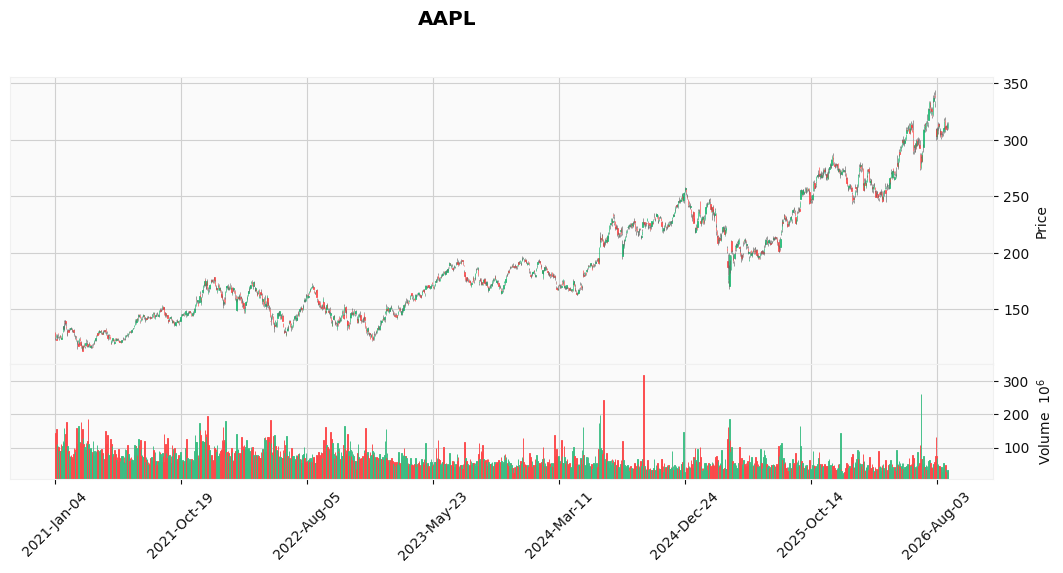

In [5]:
mpf.plot(df,type='candle', volume=True,figratio=(19,8),style='yahoo',title='AAPL')

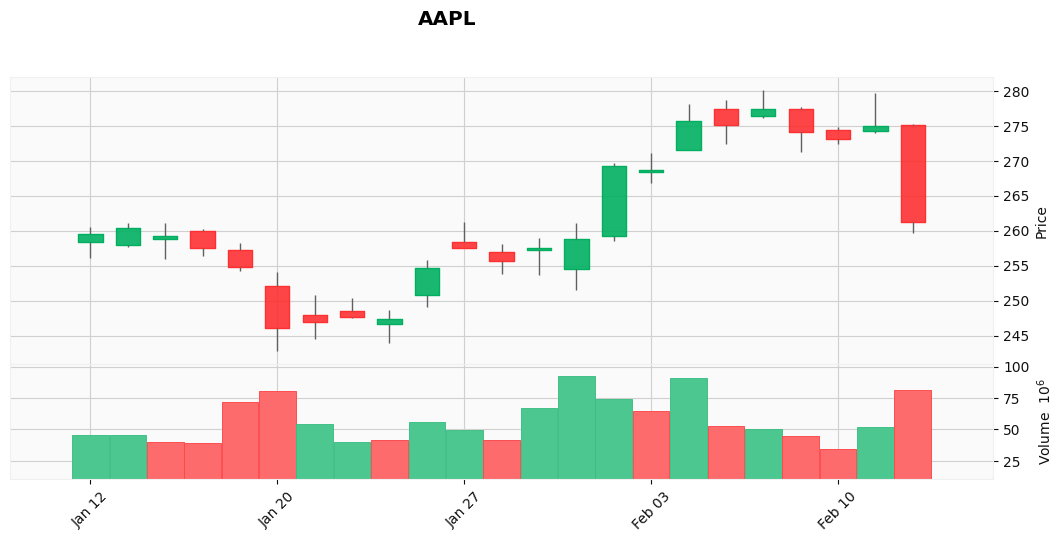

In [6]:
mpf.plot(df["2026-01-12":"2026-02-12"],type='candle', volume=True,figratio=(19,8),style='yahoo',title='AAPL')

## 4 Retornos Logarítmicos

Los retornos logarítmicos se calculan como:
$$
r_{t} = ln \left( \frac{S_t}{S_{t-1}} \right ) = ln \left( S_{t} \right) - ln \left( S_{t-1} \right)
$$

In [7]:
# Guardamos los retornos logaritmicos en una nueva columna.
df['Log Returns'] = np.log(df['Close']) - np.log(df['Close'].shift(1))
df.loc[df.index[0], 'Log Returns'] = 0
df

,Close,High,Low,Open,Volume,Log Returns
Date,,,,,,
2021-01-04,125.632515,129.709914,123.059867,129.622544,143301900,0.000000
2021-01-05,127.185799,127.894501,124.681107,125.127686,97664900,0.012288
2021-01-06,122.904518,127.224626,122.690939,123.991828,155088000,-0.034241
2021-01-07,127.098412,127.787693,124.127736,124.613141,109578200,0.033554
2021-01-08,128.195435,128.758506,126.428554,128.564332,105158200,0.008594
...,...,...,...,...,...,...
2026-08-21,309.350006,312.380005,307.010010,312.049988,46876800,-0.006284
2026-08-24,310.339996,313.359985,309.970001,311.470001,34673600,0.003195
2026-08-25,309.899994,313.589996,308.209991,310.790009,25869800,-0.001419


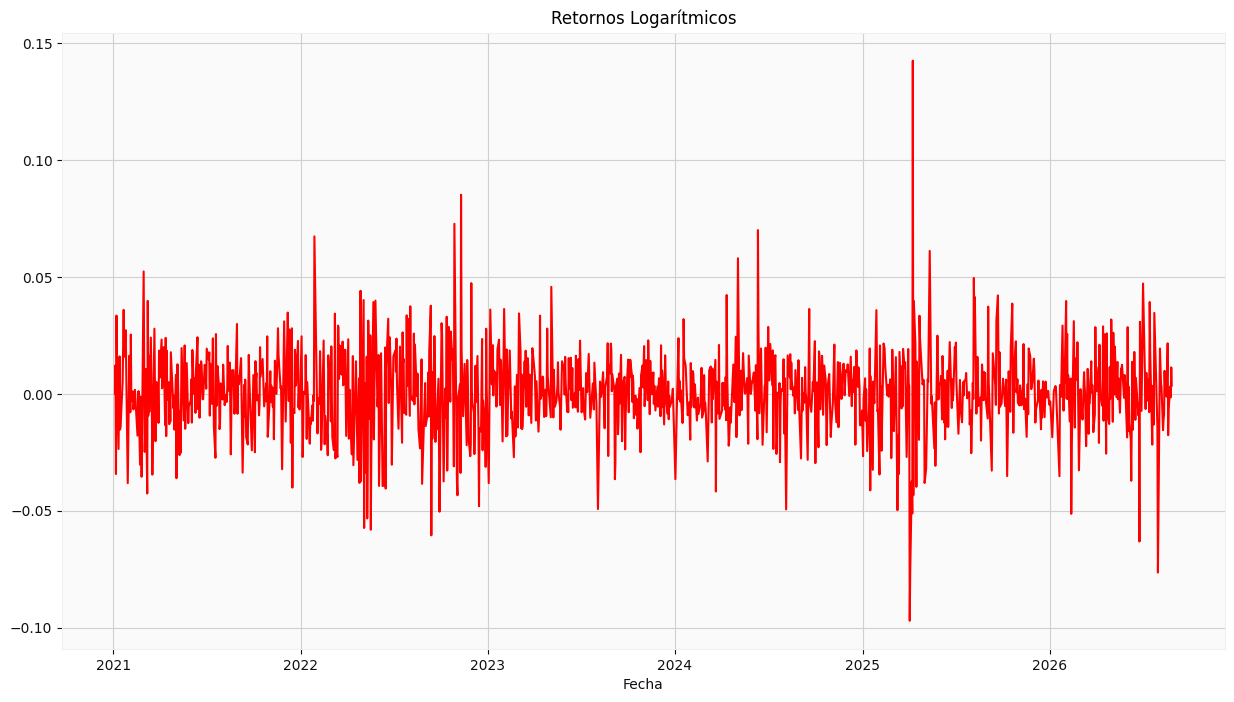

In [8]:
# Gráfico de los retornos logarítmicos
plt.figure(figsize=(15,8))
plt.plot(df['Log Returns'], color = 'red')
plt.title('Retornos Logarítmicos')
plt.xlabel('Fecha')
plt.show()

## 5. Volatilidad

La volatilidad diaria del activo es la desviación estándar de sus retornos o la raíz de la varianza:

$$vol=desv(r)=\sqrt{Var(r)}$$

En finanzas, se utiliza con mayor frecuencia la volatilidad anualizada ($\sigma$) en lugar de la volatilidad diaria. Teniendo en cuenta que en cada año hay 252 días bursátiles:

$$ \sigma^{2} = \sum_{1}^{252} Var_{diaria}$$
$$ \sigma^{2} = 252 \sigma_{diaria}^{2}$$

Se saca la raíz cuadra a ambos lados para calcular la volatilidad:

$$ \sqrt{\sigma^{2}} = \sqrt{252 \sigma_{diaria}^{2}}$$
$$ \sigma = \sigma_{diaria} \sqrt{252}$$

In [9]:
# Calculamos la volatilidad diaria con los retornos logaritmicos.
vol_d = np.std(df['Log Returns'])

# Anualizamos la volatilidad diaria.
vol_a = vol_d * np.sqrt(252)

print("Volatilidad diaria: {:.4f} %".format(100*vol_d))
print("Volatilidad anualizada: {:.4f} %".format(100*vol_a))

Volatilidad diaria: 1.7441 %
Volatilidad anualizada: 27.6868 %
